# Engine Tournament Simulation

Head-to-head round-robin across all **8 engines** (28 pairs).
Run every cell top-to-bottom. Change `GAMES` and `MAX_PLIES` in
the **Config** cell before starting.

In [1]:
%matplotlib inline
from __future__ import annotations
import math, os, random, sys
from pathlib import Path
import chess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Locate repo root and extend sys.path ────────────────────────────────
REPO = Path(os.getcwd())
if not (REPO / 'evolutionary_tournament' / '__init__.py').exists():
    REPO = REPO.parent
for _p in [str(REPO), str(REPO/'classical_minimax'), str(REPO/'berserker_2'),
           str(REPO/'berserker1'), str(REPO/'monte_carlo')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)
os.chdir(REPO)
print('Repo root:', REPO.resolve())

from evolutionary_tournament.arena import play
from evolutionary_tournament.engines import (
    ClassicalEngine, Berserker2Engine,
    Berserker1Engine, MCTSEngine, NNUEEngine,
)
from evolutionary_tournament.tunable_classical import TunableWeights
from evolutionary_tournament.evolution import run_evolution
from evolutionary_tournament.__main__ import _DEFAULT_FENS
print('All imports OK.')

Repo root: C:\Users\kliu3\Downloads\cubist
All imports OK.


## Config
Set `GAMES` and `MAX_PLIES` here. Re-run this cell and everything below
whenever you change them.

In [10]:
# ── Tune these before running the tournament ────────────────────────────
GAMES     = 5    # games per pair; increase to 20+ for real statistics
MAX_PLIES = 100  # ply cap per game (100 = ~50 moves; raises '1/2-1/2*' on timeout)
DEPTH_C   = 2    # classical / evolved / nnue search depth
DEPTH_B2  = 2    # berserker-2 search depth

# Quick evolution to produce non-default weights for 'evolved_d2'
print('Running 2-round evolution to derive evolved weights ...')
_stats = run_evolution(_DEFAULT_FENS, population=6, rounds=2, rng=random.Random(42))
evolved_weights = _stats[-1].best_weights
default_weights = TunableWeights(1.0, 1.0, 0.0)
print(f'evolved_weights: w_mat={evolved_weights.w_mat:.4f}  '
      f'w_pst={evolved_weights.w_pst:.4f}  bias={evolved_weights.w_bias:.3f}')

Running 2-round evolution to derive evolved weights ...
evolved_weights: w_mat=0.9568  w_pst=0.9481  bias=-0.050


## Engines

Defines the 8 engine factories used in every matchup.

In [3]:
# ── 8 engine factories ─────────────────────────────────────────────────
# Each lambda produces a *fresh* instance (clean transposition table) per call.
ENGINE_FACTORIES = {
    'classical_d2':  lambda: ClassicalEngine(depth=DEPTH_C),
    'classical_d3':  lambda: ClassicalEngine(depth=DEPTH_C + 1),
    'evolved_d2':    lambda: ClassicalEngine(depth=DEPTH_C, weights=evolved_weights),
    'berserker2_d2': lambda: Berserker2Engine(depth=DEPTH_B2),
    'berserker2_d3': lambda: Berserker2Engine(depth=DEPTH_B2 + 1),
    'berserker1':    lambda: Berserker1Engine(max_depth=3),
    'mcts':          lambda: MCTSEngine(max_iter=200, movetime_ms=600),
    'nnue_d2':       lambda: NNUEEngine(depth=DEPTH_C),
}

names = list(ENGINE_FACTORIES.keys())
# All C(8,2) = 28 unordered pairs
PAIRS = [(a, b) for i, a in enumerate(names) for b in names[i+1:]]
print(f'{len(names)} engines, {len(PAIRS)} pairs')

8 engines, 28 pairs


## Outcome helper + pair runner

`_outcome()` correctly handles checkmate, stalemate, threefold repetition,
50-move rule, and the ply-cap timeout (`MAX_PLIES` reached).

In [4]:
def _outcome(board, raw_result, a_is_white: bool) -> str:
    """
    Classify a completed game from player A's perspective.
    Returns 'win', 'loss', or 'draw'.

    raw_result comes directly from arena.play():
      '1-0' / '0-1' / '1/2-1/2'  -- game ended naturally
      '1/2-1/2*'                  -- ply cap hit (MAX_PLIES reached)
    """
    # Ply-cap timeout: play() appends '*' to signal the cap was hit
    if raw_result and raw_result.endswith('*'):
        return 'draw'
    # claim_draw=True mirrors arena.play(), covering threefold repetition
    # and the 50-move rule in addition to checkmate / stalemate
    if not board.is_game_over(claim_draw=True):
        return 'draw'
    result = board.result(claim_draw=True)
    if result == '1/2-1/2':
        return 'draw'
    if a_is_white:
        return 'win' if result == '1-0' else 'loss'
    return 'win' if result == '0-1' else 'loss'


def run_pair(label: str, make_a, make_b, n: int = GAMES) -> dict:
    """Play n games between two engine factories. Returns W/D/L counts."""
    w = d = l = 0
    for g in range(n):
        a_white = (g % 2 == 0)  # alternate colors
        white   = make_a() if a_white else make_b()
        black   = make_b() if a_white else make_a()
        board, res = play(white, black, max_plies=MAX_PLIES)
        o = _outcome(board, res, a_is_white=a_white)
        if o == 'win':    w += 1
        elif o == 'loss': l += 1
        else:             d += 1
        print(f'  [{label}] game {g+1}/{n}: {o}  ({res}, {len(board.move_stack)} plies)')
    tot = w + d + l
    return {'pair': label, 'W': w, 'D': d, 'L': l,
            'games': tot, 'win_rate': w / tot if tot else 0.0}

## Run tournament

Plays all 28 pairs. With `GAMES=1` this takes ~5–10 minutes at depth 2.
Colors alternate: game 0 → A is White, game 1 → A is Black, etc.

In [11]:
print(f'Starting tournament: {len(PAIRS)} pairs x {GAMES} game(s), '
      f'MAX_PLIES={MAX_PLIES} ...')
print()

rows = [
    run_pair(f'{a} vs {b}', ENGINE_FACTORIES[a], ENGINE_FACTORIES[b])
    for a, b in PAIRS
]

results_df = pd.DataFrame(rows).set_index('pair')
print()
print(f'Done. Decisive: {(results_df.W + results_df.L).sum()}  '
      f'Draws: {results_df.D.sum()}  '
      f'(out of {results_df.games.sum()} total games)')
results_df

Starting tournament: 28 pairs x 5 game(s), MAX_PLIES=100 ...

  [classical_d2 vs classical_d3] game 1/1: loss  (0-1, 54 plies)
  [classical_d2 vs evolved_d2] game 1/1: draw  (1/2-1/2, 19 plies)
  [classical_d2 vs berserker2_d2] game 1/1: loss  (0-1, 46 plies)
  [classical_d2 vs berserker2_d3] game 1/1: loss  (0-1, 46 plies)
  [classical_d2 vs berserker1] game 1/1: win  (1-0, 37 plies)
  [classical_d2 vs mcts] game 1/1: win  (1-0, 91 plies)
  [classical_d2 vs nnue_d2] game 1/1: draw  (1/2-1/2, 25 plies)
  [classical_d3 vs evolved_d2] game 1/1: draw  (1/2-1/2, 80 plies)
  [classical_d3 vs berserker2_d2] game 1/1: loss  (0-1, 60 plies)
  [classical_d3 vs berserker2_d3] game 1/1: loss  (0-1, 60 plies)
  [classical_d3 vs berserker1] game 1/1: win  (1-0, 31 plies)
  [classical_d3 vs mcts] game 1/1: win  (1-0, 15 plies)
  [classical_d3 vs nnue_d2] game 1/1: draw  (1/2-1/2, 52 plies)
  [evolved_d2 vs berserker2_d2] game 1/1: loss  (0-1, 46 plies)
  [evolved_d2 vs berserker2_d3] game 1/1: loss 

,W,D,L,games,win_rate
pair,,,,,
classical_d2 vs classical_d3,0,0,1,1,0.0
classical_d2 vs evolved_d2,0,1,0,1,0.0
classical_d2 vs berserker2_d2,0,0,1,1,0.0
classical_d2 vs berserker2_d3,0,0,1,1,0.0
classical_d2 vs berserker1,1,0,0,1,1.0
classical_d2 vs mcts,1,0,0,1,1.0
classical_d2 vs nnue_d2,0,1,0,1,0.0
classical_d3 vs evolved_d2,0,1,0,1,0.0
classical_d3 vs berserker2_d2,0,0,1,1,0.0


## Statistics — Wilson 95% confidence intervals

In [6]:
from IPython.display import Markdown, display

def wilson_95(wins: int, n: int) -> tuple[float, float]:
    """Wilson score 95% confidence interval for a win proportion."""
    if n <= 0:
        return float('nan'), float('nan')
    p, z, z2 = wins / n, 1.96, 1.96 ** 2
    denom  = 1 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    half   = z * math.sqrt(p * (1 - p) / n + z2 / (4 * n * n)) / denom
    return center - half, center + half

ci: dict[str, tuple[float, float]] = {}
for pair, row in results_df.iterrows():
    ci[pair] = wilson_95(int(row['W']), int(row['games']))

lines = [f'**Tournament results ({GAMES} game(s) per pair, MAX_PLIES={MAX_PLIES})**', '']
for pair, row in results_df.iterrows():
    lo, hi = ci[pair]
    lo_s = f'{lo*100:.0f}' if not math.isnan(lo) else 'n/a'
    hi_s = f'{hi*100:.0f}' if not math.isnan(hi) else 'n/a'
    lines.append(
        f'- **{pair}**: {int(row["W"])}W / {int(row["D"])}D / {int(row["L"])}L  '
        f'(win rate {row["win_rate"]*100:.0f}%, 95% CI [{lo_s}%–{hi_s}%])'
    )
if GAMES < 10:
    lines += ['', '> *1 game per pair is too few for reliable CIs — '
              'increase `GAMES` for meaningful statistics.*']
display(Markdown('\n'.join(lines)))

results_df['ci_lo'] = [ci[p][0] for p in results_df.index]
results_df['ci_hi'] = [ci[p][1] for p in results_df.index]
results_df[['W','D','L','win_rate','ci_lo','ci_hi']].round(3)

**Tournament results (1 game(s) per pair, MAX_PLIES=100)**

- **classical_d2 vs classical_d3**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **classical_d2 vs evolved_d2**: 0W / 1D / 0L  (win rate 0%, 95% CI [0%–79%])
- **classical_d2 vs berserker2_d2**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **classical_d2 vs berserker2_d3**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **classical_d2 vs berserker1**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **classical_d2 vs mcts**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **classical_d2 vs nnue_d2**: 0W / 1D / 0L  (win rate 0%, 95% CI [0%–79%])
- **classical_d3 vs evolved_d2**: 0W / 1D / 0L  (win rate 0%, 95% CI [0%–79%])
- **classical_d3 vs berserker2_d2**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **classical_d3 vs berserker2_d3**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **classical_d3 vs berserker1**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **classical_d3 vs mcts**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **classical_d3 vs nnue_d2**: 0W / 1D / 0L  (win rate 0%, 95% CI [0%–79%])
- **evolved_d2 vs berserker2_d2**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **evolved_d2 vs berserker2_d3**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **evolved_d2 vs berserker1**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **evolved_d2 vs mcts**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **evolved_d2 vs nnue_d2**: 0W / 1D / 0L  (win rate 0%, 95% CI [0%–79%])
- **berserker2_d2 vs berserker2_d3**: 0W / 1D / 0L  (win rate 0%, 95% CI [0%–79%])
- **berserker2_d2 vs berserker1**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **berserker2_d2 vs mcts**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **berserker2_d2 vs nnue_d2**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **berserker2_d3 vs berserker1**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **berserker2_d3 vs mcts**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **berserker2_d3 vs nnue_d2**: 1W / 0D / 0L  (win rate 100%, 95% CI [21%–100%])
- **berserker1 vs mcts**: 0W / 1D / 0L  (win rate 0%, 95% CI [0%–79%])
- **berserker1 vs nnue_d2**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])
- **mcts vs nnue_d2**: 0W / 0D / 1L  (win rate 0%, 95% CI [0%–79%])

> *1 game per pair is too few for reliable CIs — increase `GAMES` for meaningful statistics.*

,W,D,L,win_rate,ci_lo,ci_hi
pair,,,,,,
classical_d2 vs classical_d3,0,0,1,0.0,0.000,0.793
classical_d2 vs evolved_d2,0,1,0,0.0,0.000,0.793
classical_d2 vs berserker2_d2,0,0,1,0.0,0.000,0.793
classical_d2 vs berserker2_d3,0,0,1,0.0,0.000,0.793
classical_d2 vs berserker1,1,0,0,1.0,0.207,1.000
classical_d2 vs mcts,1,0,0,1.0,0.207,1.000
classical_d2 vs nnue_d2,0,1,0,0.0,0.000,0.793
classical_d3 vs evolved_d2,0,1,0,0.0,0.000,0.793
classical_d3 vs berserker2_d2,0,0,1,0.0,0.000,0.793


## Charts

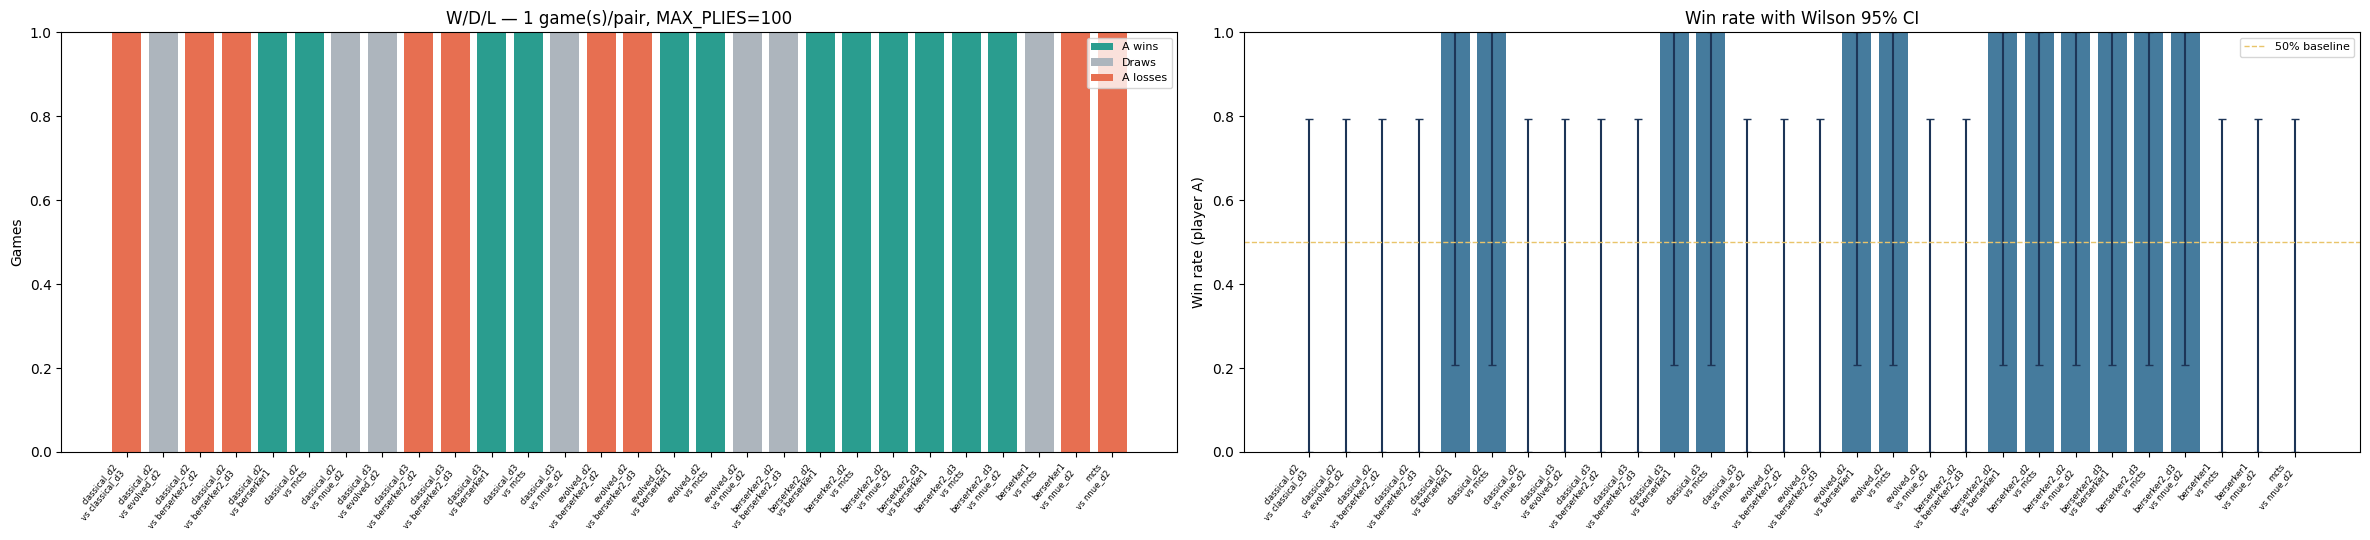

Figure saved to evolutionary_tournament/tournament_sim_results.png


In [9]:
n = len(results_df)
short = [p.replace(' vs ', '\nvs ') for p in results_df.index]
x = np.arange(n)

fig, axes = plt.subplots(1, 2, figsize=(max(18, n * 0.85), 5.5))

# ── W/D/L stacked bar ───────────────────────────────────────────────────
ax = axes[0]
ax.bar(x, results_df['W'], color='#2a9d8f', label='A wins')
ax.bar(x, results_df['D'], bottom=results_df['W'], color='#adb5bd', label='Draws')
ax.bar(x, results_df['L'], bottom=results_df['W'] + results_df['D'], color='#e76f51', label='A losses')

ax.set_xticks(x)
ax.set_xticklabels(short, fontsize=6, rotation=50, ha='right')
ax.set_ylabel('Games')
ax.legend(fontsize=8)
ax.set_title(f'W/D/L — {GAMES} game(s)/pair, MAX_PLIES={MAX_PLIES}')

# ── Win-rate bars with Wilson CI ────────────────────────────────────────
ax = axes[1]

wr = results_df['win_rate'].to_numpy()
ci_lo = results_df['ci_lo'].to_numpy()
ci_hi = results_df['ci_hi'].to_numpy()

# Replace NaNs with wr using numpy (correct way)
ci_lo = np.where(np.isnan(ci_lo), wr, ci_lo)
ci_hi = np.where(np.isnan(ci_hi), wr, ci_hi)

err_lo = wr - ci_lo
err_hi = ci_hi - wr

ax.bar(x, wr, color='#457b9d', yerr=[err_lo, err_hi], capsize=3, ecolor='#1d3557')
ax.axhline(0.5, color='#e9c46a', linestyle='--', linewidth=1, label='50% baseline')

ax.set_xticks(x)
ax.set_xticklabels(short, fontsize=6, rotation=50, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Win rate (player A)')
ax.legend(fontsize=8)
ax.set_title('Win rate with Wilson 95% CI')

plt.tight_layout()
plt.savefig('evolutionary_tournament/tournament_sim_results.png', dpi=120, bbox_inches='tight')
plt.show()

print('Figure saved to evolutionary_tournament/tournament_sim_results.png')